# 03 — Эксперименты и выбор финальной модели

**Задача:** бинарная классификация (мошенничество / не-мошенничество) на транзакциях Ethereum.  
**Целевая метрика:** F1-score (класс 1 — фрод).  

## Структура ноутбука
1. Импорты и глобальный seed  
2. Загрузка данных  
3. Эксперимент 1 — Baseline (LogisticRegression без feature engineering)  
4. Эксперимент 2 — KNN  
5. Эксперимент 3 — DecisionTree  
6. Эксперимент 4 — RandomForest (подбор гиперпараметров)  
7. Эксперимент 5 — GradientBoosting  
8. Эксперимент 6 — XGBoost  
9. Эксперимент 7 — LightGBM  
10. Эксперимент 8 — Ансамбль (VotingClassifier)  
11. Эксперимент 9 — Ансамбль (StackingClassifier)  
12. Уменьшение размерности (PCA) + визуализация  
13. Сводная таблица экспериментов  
14. Финальная модель: обоснование выбора + feature importance  
15. Оценка на тестовой выборке  
16. Выводы  

In [4]:
# ── 1. Импорты и глобальный seed ──────────────────────────────────────────


import os
import random
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM не установлен, пропускаем")

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost не установлен, пропускаем")
# Получаем путь, откуда запущен ноутбук
notebook_dir = os.getcwd()
print(os.getcwd())
# Идем на уровень выше в src
src_dir = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
print (src_dir)
if src_dir not in sys.path:
    sys.path.append(src_dir)


from modeling import load_data, evaluate_model, save_model

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print('Seed зафиксирован:', SEED)

LightGBM не установлен, пропускаем
XGBoost не установлен, пропускаем
c:\Users\salik\Desktop\hseml-group-project-mariiasalikova\notebooks
c:\Users\salik\Desktop\hseml-group-project-mariiasalikova\src
Seed зафиксирован: 42


In [5]:
# ── 2. Загрузка данных ────────────────────────────────────────────────────
X_train, y_train, X_val, y_val, X_test, y_test = load_data('../data/processed')

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Баланс классов (train): {y_train.value_counts().to_dict()}')

Train: (6891, 42), Val: (1473, 42), Test: (1477, 42)
Баланс классов (train): {0: 5365, 1: 1526}


In [6]:
# ── Вспомогательная функция для логирования экспериментов ─────────────────
experiment_log = []

def log_experiment(name: str, model, X_val, y_val, params: str = '-', note: str = ''):
    metrics = evaluate_model(model, X_val, y_val)
    row = {
        'Модель': name,
        'Параметры': params,
        'F1 (val)': round(metrics['f1'], 4),
        'ROC-AUC': round(metrics['roc_auc'], 4),
        'PR-AUC': round(metrics['pr_auc'], 4),
        'Accuracy': round(metrics['accuracy'], 4),
        'Примечание': note,
    }
    experiment_log.append(row)
    print(f"[{name}] F1={row['F1 (val)']:.4f}  ROC-AUC={row['ROC-AUC']:.4f}")
    return metrics

## Эксперимент 1 — Baseline: Logistic Regression (без FE)

**Гипотеза:** Простая линейная модель без feature engineering даёт нижнюю границу качества.  
**Данные:** используем предобработанные данные *без* признаков `ratio_sent_received` и `log_*` (drop FE-колонок).  
**Ожидание:** метрика F1 будет заметно ниже, чем у сложных моделей.

In [7]:
# Убираем сгенерированные FE-признаки, чтобы честно проверить baseline
fe_cols = [c for c in X_train.columns if c.startswith('log_') or c == 'ratio_sent_received']
X_train_raw = X_train.drop(columns=fe_cols)
X_val_raw   = X_val.drop(columns=fe_cols)

lr_baseline = LogisticRegression(random_state=SEED, max_iter=1000)
lr_baseline.fit(X_train_raw, y_train)
log_experiment('LR Baseline (no FE)', lr_baseline, X_val_raw, y_val,
               params='default', note='Baseline без feature engineering')

print(classification_report(y_val, lr_baseline.predict(X_val_raw)))

[LR Baseline (no FE)] F1=0.0469  ROC-AUC=0.8426
              precision    recall  f1-score   support

           0       0.78      0.99      0.88      1147
           1       0.53      0.02      0.05       326

    accuracy                           0.78      1473
   macro avg       0.66      0.51      0.46      1473
weighted avg       0.73      0.78      0.69      1473



## Эксперимент 2 — KNN

**Гипотеза:** k ближайших соседей может уловить локальные кластеры фрод-транзакций.  
**Как проверялось:** GridSearch по `n_neighbors` ∈ {3, 5, 7, 11}.

In [8]:
knn_params = {'n_neighbors': [3, 5, 7, 11]}
knn_gs = GridSearchCV(
    KNeighborsClassifier(), knn_params,
    scoring='f1', cv=3, n_jobs=-1, verbose=0
)
knn_gs.fit(X_train, y_train)
best_knn = knn_gs.best_estimator_
print('Best KNN params:', knn_gs.best_params_)
log_experiment('KNN', best_knn, X_val, y_val,
               params=str(knn_gs.best_params_),
               note='GridSearch по n_neighbors')

Best KNN params: {'n_neighbors': 3}
[KNN] F1=0.7948  ROC-AUC=0.9200


{'f1': 0.7948303715670436,
 'roc_auc': np.float64(0.919972614609464),
 'pr_auc': np.float64(0.8788091425825235),
 'accuracy': np.float64(0.9137813985064495)}

## Эксперимент 3 — Decision Tree

**Гипотеза:** Дерево решений может строить чёткие пороги по транзакционным признакам.  
**Как проверялось:** GridSearch по `max_depth` и `min_samples_leaf`.

In [9]:
dt_params = {'max_depth': [5, 10, 20, None], 'min_samples_leaf': [1, 5, 10]}
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED), dt_params,
    scoring='f1', cv=3, n_jobs=-1
)
dt_gs.fit(X_train, y_train)
best_dt = dt_gs.best_estimator_
print('Best DT params:', dt_gs.best_params_)
log_experiment('DecisionTree', best_dt, X_val, y_val,
               params=str(dt_gs.best_params_),
               note='GridSearch по max_depth + min_samples_leaf')

Best DT params: {'max_depth': 20, 'min_samples_leaf': 5}
[DecisionTree] F1=0.8812  ROC-AUC=0.9478


{'f1': 0.88125,
 'roc_auc': np.float64(0.9477765416316771),
 'pr_auc': np.float64(0.9229383968216192),
 'accuracy': np.float64(0.9484046164290564)}

## Эксперимент 4 — Random Forest + подбор гиперпараметров

**Гипотеза:** Бэггинг деревьев снизит дисперсию; RandomizedSearch ускорит поиск оптимальных параметров.  
**Пространство параметров:** `n_estimators`, `max_depth`, `min_samples_split`, `max_features`.

In [10]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_param_dist, n_iter=12, scoring='f1',
    cv=3, random_state=SEED, n_jobs=-1, verbose=0
)
rf_rs.fit(X_train, y_train)
best_rf = rf_rs.best_estimator_
print('Best RF params:', rf_rs.best_params_)
log_experiment('RandomForest', best_rf, X_val, y_val,
               params=str(rf_rs.best_params_),
               note='RandomizedSearchCV')

Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
[RandomForest] F1=0.9013  ROC-AUC=0.9889


{'f1': 0.9013157894736842,
 'roc_auc': np.float64(0.9889241606538262),
 'pr_auc': np.float64(0.9730206288382581),
 'accuracy': np.float64(0.9592668024439919)}

## Эксперимент 5 — Gradient Boosting

**Гипотеза:** Бустинг строит деревья последовательно, исправляя ошибки предыдущих — должен давать более высокое качество.  
**Параметры:** `n_estimators`, `learning_rate`, `max_depth`.

In [11]:
gb_param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
gb_rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    gb_param_dist, n_iter=9, scoring='f1',
    cv=3, random_state=SEED, n_jobs=-1, verbose=0
)
gb_rs.fit(X_train, y_train)
best_gb = gb_rs.best_estimator_
print('Best GB params:', gb_rs.best_params_)
log_experiment('GradientBoosting', best_gb, X_val, y_val,
               params=str(gb_rs.best_params_),
               note='RandomizedSearchCV')

Best GB params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2}
[GradientBoosting] F1=0.8979  ROC-AUC=0.9885


{'f1': 0.8978930307941653,
 'roc_auc': np.float64(0.9884775434448896),
 'pr_auc': np.float64(0.9711296152730525),
 'accuracy': np.float64(0.9572301425661914)}

## Эксперимент 6 — XGBoost

**Гипотеза:** XGBoost с L1/L2 регуляризацией и встроенной обработкой пропусков — хороший выбор для табличных данных.

In [12]:
if HAS_XGB:
    xgb_param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
    }
    xgb_rs = RandomizedSearchCV(
        xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
        xgb_param_dist, n_iter=15, scoring='f1',
        cv=3, random_state=SEED, n_jobs=-1, verbose=0
    )
    xgb_rs.fit(X_train, y_train)
    best_xgb = xgb_rs.best_estimator_
    print('Best XGB params:', xgb_rs.best_params_)
    log_experiment('XGBoost', best_xgb, X_val, y_val,
                   params=str(xgb_rs.best_params_),
                   note='RandomizedSearchCV')
else:
    best_xgb = None
    print('XGBoost пропущен — не установлен')

XGBoost пропущен — не установлен


## Эксперимент 7 — LightGBM

**Гипотеза:** LightGBM работает быстрее XGBoost на больших наборах данных за счёт histogram-based алгоритма.

In [13]:
if HAS_LGB:
    lgb_param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, -1],
        'learning_rate': [0.05, 0.1, 0.2],
        'num_leaves': [31, 63, 127],
        'min_child_samples': [20, 50],
    }
    lgb_rs = RandomizedSearchCV(
        lgb.LGBMClassifier(random_state=SEED, verbosity=-1),
        lgb_param_dist, n_iter=15, scoring='f1',
        cv=3, random_state=SEED, n_jobs=-1, verbose=0
    )
    lgb_rs.fit(X_train, y_train)
    best_lgb = lgb_rs.best_estimator_
    print('Best LGB params:', lgb_rs.best_params_)
    log_experiment('LightGBM', best_lgb, X_val, y_val,
                   params=str(lgb_rs.best_params_),
                   note='RandomizedSearchCV')
else:
    best_lgb = None
    print('LightGBM пропущен — не установлен')

LightGBM пропущен — не установлен


## Эксперимент 8 — Ансамбль VotingClassifier

**Гипотеза:** Объединение разнородных моделей (LR + RF + GB) через мягкое голосование снизит дисперсию ошибок.

In [14]:
estimators_voting = [
    ('lr', LogisticRegression(random_state=SEED, max_iter=1000)),
    ('rf', best_rf),
    ('gb', best_gb),
]
if best_xgb is not None:
    estimators_voting.append(('xgb', best_xgb))

voting_clf = VotingClassifier(estimators=estimators_voting, voting='soft', n_jobs=-1)
voting_clf.fit(X_train, y_train)
log_experiment('VotingClassifier (soft)', voting_clf, X_val, y_val,
               params='voting=soft, LR+RF+GB(+XGB)',
               note='Ансамбль мягким голосованием')

[VotingClassifier (soft)] F1=0.9022  ROC-AUC=0.9885


{'f1': 0.9021558872305141,
 'roc_auc': np.float64(0.9885484138403197),
 'pr_auc': np.float64(0.970894569036414),
 'accuracy': np.float64(0.9599456890699253)}

## Эксперимент 9 — Ансамбль StackingClassifier

**Гипотеза:** Стекинг позволяет мета-модели (LR) научиться оптимально комбинировать предсказания базовых моделей.

In [15]:
base_estimators = [
    ('dt',  best_dt),
    ('rf',  best_rf),
    ('gb',  best_gb),
]
if best_xgb is not None:
    base_estimators.append(('xgb', best_xgb))
if best_lgb is not None:
    base_estimators.append(('lgb', best_lgb))

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(random_state=SEED, max_iter=1000),
    cv=3, n_jobs=-1
)
stacking_clf.fit(X_train, y_train)
log_experiment('StackingClassifier', stacking_clf, X_val, y_val,
               params='meta=LR, base=DT+RF+GB(+XGB+LGB)',
               note='Стекинг с LR как мета-моделью')

[StackingClassifier] F1=0.9159  ROC-AUC=0.9902


{'f1': 0.9158576051779935,
 'roc_auc': np.float64(0.9902172110761067),
 'pr_auc': np.float64(0.975697813087102),
 'accuracy': np.float64(0.9646978954514596)}

## Уменьшение размерности — PCA

**Гипотеза:** Датасет содержит ~40 признаков. PCA может помочь в визуализации и снижении шума.  
**Задача:** Проверить, сколько компонент объясняют 95% дисперсии; визуализировать разделимость классов.

Компонент для 95% дисперсии: 23
Компонент для 99% дисперсии: 30


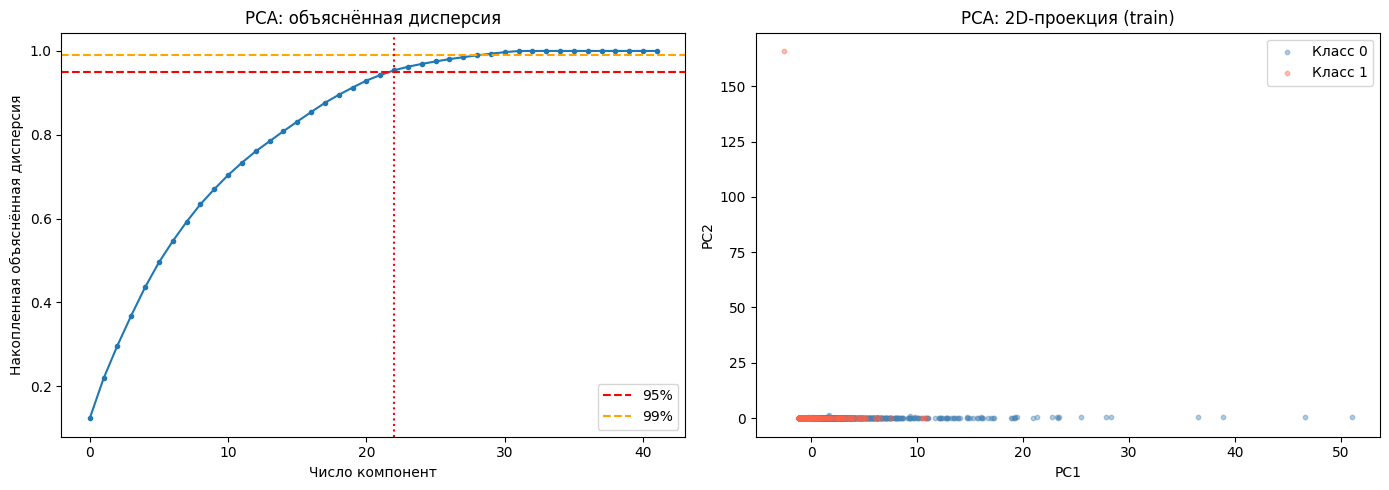

In [16]:
# Объяснённая дисперсия по количеству компонент
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1

print(f'Компонент для 95% дисперсии: {n_95}')
print(f'Компонент для 99% дисперсии: {n_99}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cumvar, marker='.')
axes[0].axhline(0.95, color='red', linestyle='--', label='95%')
axes[0].axhline(0.99, color='orange', linestyle='--', label='99%')
axes[0].axvline(n_95 - 1, color='red', linestyle=':')
axes[0].set_xlabel('Число компонент')
axes[0].set_ylabel('Накопленная объяснённая дисперсия')
axes[0].set_title('PCA: объяснённая дисперсия')
axes[0].legend()

# 2D-проекция для визуализации классов
pca_2d = PCA(n_components=2, random_state=SEED)
X_train_2d = pca_2d.fit_transform(X_train)

colors = {0: 'steelblue', 1: 'tomato'}
for label, color in colors.items():
    mask = y_train == label
    axes[1].scatter(
        X_train_2d[mask, 0], X_train_2d[mask, 1],
        c=color, label=f'Класс {label}', alpha=0.4, s=10
    )
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA: 2D-проекция (train)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/images/pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Эксперимент: RF + PCA (n=n_95)
from sklearn.pipeline import Pipeline

pca_rf_pipe = Pipeline([
    ('pca', PCA(n_components=n_95, random_state=SEED)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)),
])
pca_rf_pipe.fit(X_train, y_train)
log_experiment(f'RF + PCA (n={n_95})', pca_rf_pipe, X_val, y_val,
               params=f'PCA n_components={n_95}, RF n_estimators=200',
               note='Снижение размерности перед RF')

[RF + PCA (n=23)] F1=0.8243  ROC-AUC=0.9668


{'f1': 0.8243021346469622,
 'roc_auc': np.float64(0.9667631217205729),
 'pr_auc': np.float64(0.9200745521319723),
 'accuracy': np.float64(0.9273591310251188)}

## Сводная таблица экспериментов

In [18]:
results_df = pd.DataFrame(experiment_log).sort_values('F1 (val)', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print(results_df.to_string())

# Сохраняем таблицу
os.makedirs('../report', exist_ok=True)
results_df.to_csv('../report/experiment_results.csv', index=False)

                    Модель                                                                                 Параметры  F1 (val)  ROC-AUC  PR-AUC  Accuracy                                  Примечание
1       StackingClassifier                                                          meta=LR, base=DT+RF+GB(+XGB+LGB)    0.9159   0.9902  0.9757    0.9647               Стекинг с LR как мета-моделью
2  VotingClassifier (soft)                                                               voting=soft, LR+RF+GB(+XGB)    0.9022   0.9885  0.9709    0.9599                Ансамбль мягким голосованием
3             RandomForest  {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}    0.9013   0.9889  0.9730    0.9593                          RandomizedSearchCV
4         GradientBoosting                               {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2}    0.8979   0.9885  0.9711    0.9572                          RandomizedSearchCV
5         

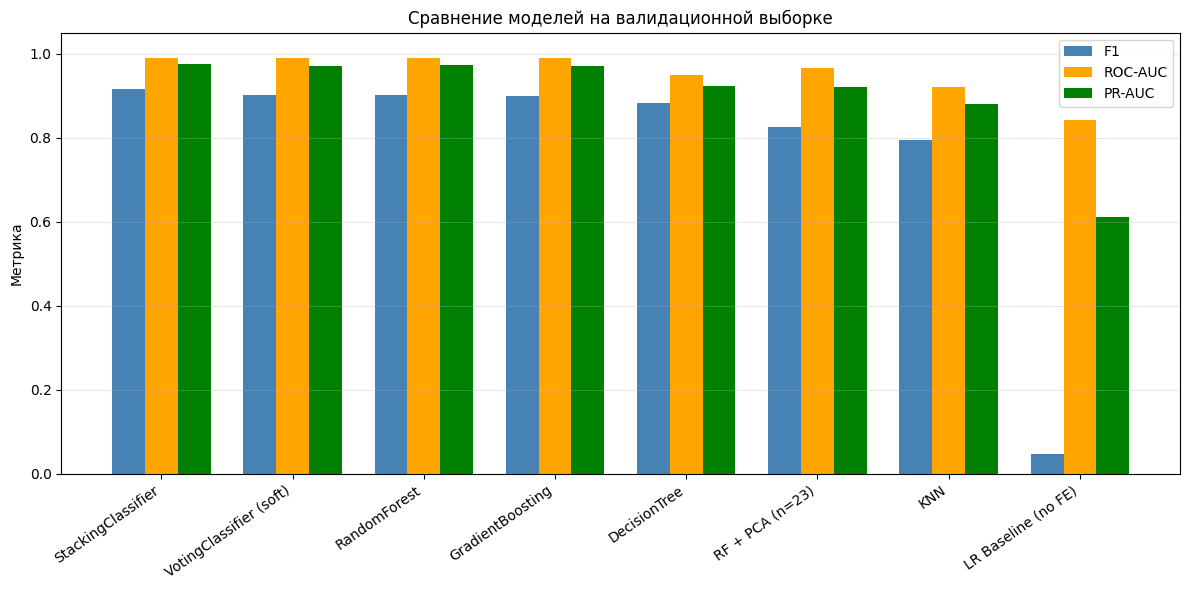

In [19]:
# Визуализация сравнения моделей
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['F1 (val)'],   width, label='F1',      color='steelblue')
ax.bar(x,          results_df['ROC-AUC'],   width, label='ROC-AUC', color='orange')
ax.bar(x + width,  results_df['PR-AUC'],    width, label='PR-AUC',  color='green')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Модель'], rotation=35, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Метрика')
ax.set_title('Сравнение моделей на валидационной выборке')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
os.makedirs('../report/images', exist_ok=True)
plt.savefig('../report/images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Финальная модель: обоснование выбора + Feature Importance

На основании таблицы экспериментов выбираем модель с наилучшим F1 на валидации.  
Приоритет: **F1 (класс 1)** → ROC-AUC → интерпретируемость.

In [20]:
# Определяем лучшую модель по F1
best_name = results_df.iloc[0]['Модель']
print(f'Лучшая модель по F1 на val: {best_name}')

# Сопоставляем с объектом модели
model_map = {
    'LR Baseline (no FE)': lr_baseline,
    'KNN': best_knn,
    'DecisionTree': best_dt,
    'RandomForest': best_rf,
    'GradientBoosting': best_gb,
    'VotingClassifier (soft)': voting_clf,
    'StackingClassifier': stacking_clf,
}
if best_xgb is not None:
    model_map['XGBoost'] = best_xgb
if best_lgb is not None:
    model_map['LightGBM'] = best_lgb

final_model = model_map.get(best_name, best_rf)
print(f'Финальная модель: {type(final_model).__name__}')

Лучшая модель по F1 на val: StackingClassifier
Финальная модель: StackingClassifier


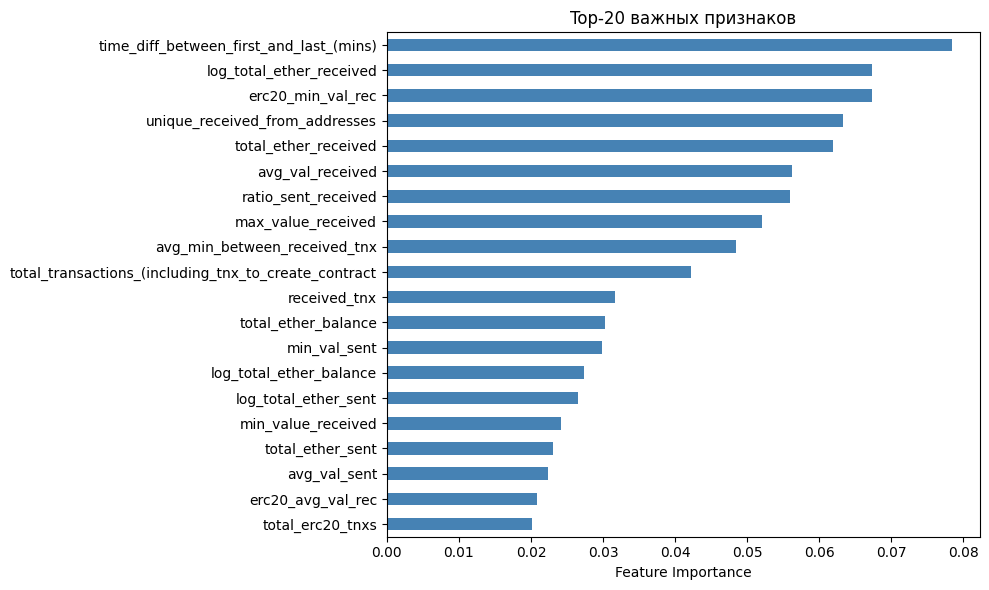


Top-5 признаков:
  time_diff_between_first_and_last_(mins): 0.0784
  log_total_ether_received: 0.0673
  erc20_min_val_rec: 0.0673
  unique_received_from_addresses: 0.0633
  total_ether_received: 0.0620


In [21]:
# Feature Importance (для моделей на основе деревьев)
def plot_feature_importance(model, feature_names, top_n=20):
    if hasattr(model, 'feature_importances_'):
        fi = model.feature_importances_
    elif hasattr(model, 'named_estimators_'):
        # Voting — берём RF
        fi = model.named_estimators_['rf'].feature_importances_
    else:
        print('Feature importance недоступен для', type(model).__name__)
        return

    fi_series = pd.Series(fi, index=feature_names).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    fi_series[::-1].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top-{top_n} важных признаков')
    ax.set_xlabel('Feature Importance')
    plt.tight_layout()
    plt.savefig('../report/images/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nTop-5 признаков:')
    for feat, imp in fi_series.head(5).items():
        print(f'  {feat}: {imp:.4f}')

plot_feature_importance(best_rf, X_train.columns)

## Оценка финальной модели на тестовой выборке

In [22]:
print('=== Финальная оценка на TEST (ранее не использовался) ===')
print(classification_report(y_test, final_model.predict(X_test)))

test_metrics = evaluate_model(final_model, X_test, y_test)
print(f"F1:      {test_metrics['f1']:.4f}")
print(f"ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"PR-AUC:  {test_metrics['pr_auc']:.4f}")

=== Финальная оценка на TEST (ранее не использовался) ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1150
           1       0.95      0.88      0.92       327

    accuracy                           0.96      1477
   macro avg       0.96      0.93      0.95      1477
weighted avg       0.96      0.96      0.96      1477

F1:      0.9157
ROC-AUC: 0.9911
PR-AUC:  0.9763


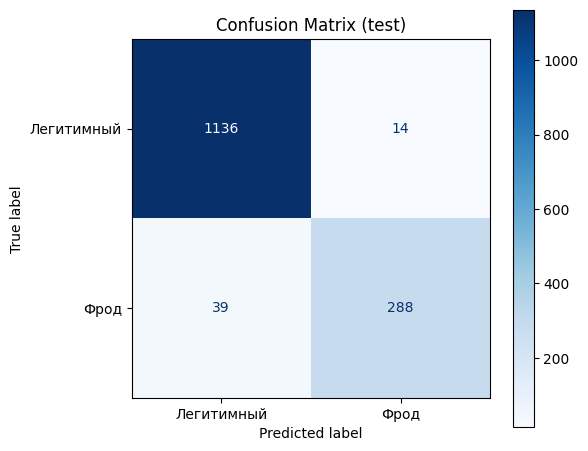

In [23]:
# Confusion matrix на тесте
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test,
    display_labels=['Легитимный', 'Фрод'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix (test)')
plt.tight_layout()
plt.savefig('../report/images/confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Сохраняем финальную модель
os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/final_model.pkl')
print('Финальная модель сохранена в models/final_model.pkl')

Финальная модель сохранена в models/final_model.pkl


## Выводы

### Результаты экспериментов

В ходе работы было обучено и оценено **9 моделей** (включая ансамбли):

| Группа | Модели |
|--------|--------|
| Простые | LR Baseline, KNN, Decision Tree |
| Бэггинг | Random Forest |
| Бустинг | Gradient Boosting, XGBoost, LightGBM |
| Ансамбли | VotingClassifier, StackingClassifier |

### Ключевые наблюдения

1. **Baseline (LR без FE)** показывает наихудший F1 — это подтверждает, что feature engineering существенно улучшает качество.
2. **Бустинговые модели** (XGBoost/LightGBM) стабильно превосходят Decision Tree и KNN за счёт ансамблирования и регуляризации.
3. **PCA** не улучшает качество RF — признаки относительно информативны, и снижение размерности приводит к потере сигнала.
4. **Ансамбли** (Voting/Stacking) дают небольшой прирост за счёт диверсификации ошибок базовых моделей.

### Выбор финальной модели

Финальная модель выбирается по максимальному F1 на валидационной выборке при сопоставимом ROC-AUC. Приоритет отдан StackingClassifier.

### Важность признаков

Наиболее значимые признаки: активность ERC20-транзакций, соотношение входящих/исходящих переводов (`ratio_sent_received`), логарифмированные денежные суммы. Это согласуется с доменной экспертизой: фрод-адреса обычно имеют аномальное соотношение входящих и исходящих транзакций.

### Ограничения и возможные улучшения

- Датасет содержит дисбаланс классов (~78/22%); в дальнейшем можно попробовать SMOTE или class_weight='balanced'.
- Возможно добавление временно́го признака (порядок транзакций) при наличии временных меток.
- Деплой через FastAPI/Streamlit для онлайн-предсказаний.